# Работа со сложными данными — простыми словами

**Сложные данные** здесь — это не таблицы «возраст / зарплата», а:
- **тексты** (письма, отзывы, SMS);
- **изображения** (картинки из пикселей).

Компьютер не понимает слова и картинки «как человек».  
Ему нужны **числа**. Вся тема урока — как превратить текст/картинку в числа и что с ними делать.

### План
1. [Словарь](#dict)
2. [Текст → числа: CountVectorizer (мешок слов)](#bow)
3. [N-граммы](#ngram)
4. [TF-IDF — важные слова](#tfidf)
5. [Токенизация простыми словами](#token)
6. [Мини-задача: спам / не спам](#spam)
7. [Наивный Байес одной картинкой в голове](#bayes)
8. [Изображения и PCA](#pca)
9. [Итог](#summary)

Нужно: `numpy`, `pandas`, `matplotlib`, `scikit-learn`.  
Запускайте ячейки **сверху вниз**.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

np.random.seed(42)


<a id="dict"></a>
## 1. Словарь

| Термин | Простыми словами |
|--------|------------------|
| **Корпус** | Набор текстов (например, 4 письма или 1000 SMS) |
| **Токен** | Кусочек текста: обычно слово |
| **Словарь (vocabulary)** | Все уникальные слова, которые модель знает |
| **Векторизация** | Превращение текста в список/строку чисел |
| **Мешок слов (Bag of Words)** | Считаем, **сколько раз** каждое слово встретилось (порядок почти не важен) |
| **Разреженная матрица** | Много нулей: в каждом тексте есть лишь малая часть всех слов |
| **TF-IDF** | Частые «везде» слова получают меньший вес, редкие важные — больший |
| **Эмбеддинг** | Умное числовое представление смысла (в этом ноутбуке почти не трогаем) |
| **Пиксель** | Одна клеточка картинки с яркостью/цветом |
| **PCA** | Сжатие: оставляем главные направления вариации, выбрасываем шум |


<a id="bow"></a>
## 2. CountVectorizer — «мешок слов»

### Идея
Берём все тексты → собираем список всех слов → для каждого текста пишем **счётчики**.

### Элементарный пример
Три коротких фразы:

1. `кот спит`  
2. `кот ест`  
3. `пёс спит`

Словарь: `кот`, `спит`, `ест`, `пёс`

| Текст | кот | спит | ест | пёс |
|-------|-----|------|-----|-----|
| 1 | 1 | 1 | 0 | 0 |
| 2 | 1 | 0 | 1 | 0 |
| 3 | 0 | 1 | 0 | 1 |

Это и есть **мешок слов**: порядок («кот спит» vs «спит кот») почти теряется, важны **частоты**.


In [2]:
# Маленький корпус — как 4 коротких документа
corpus = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?",
]

# CountVectorizer сам режет на слова и считает частоты
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(corpus)  # учим словарь + превращаем тексты в числа

print("Словарь:", vectorizer.get_feature_names_out())
print("Размер матрицы (документы × слова):", X_counts.shape)

# Таблица: строки — тексты, столбцы — слова, числа — сколько раз встретилось
pd.DataFrame(X_counts.toarray(), columns=vectorizer.get_feature_names_out())


Словарь: ['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
Размер матрицы (документы × слова): (4, 9)


,and,document,first,is,one,second,the,third,this
0,0,1,1,1,0,0,1,0,1
1,0,2,0,1,0,1,1,0,1
2,1,0,0,1,1,0,1,1,1
3,0,1,1,1,0,0,1,0,1


**Вывод.**  
Текст стал таблицей чисел. Модель ML уже может на этом учиться.  
Минус мешка слов: слово `document`, которое везде, и редкое важное слово выглядят «одинаково важными», если просто считать частоты.


<a id="ngram"></a>
## 3. N-граммы — кусочки из N слов подряд

**Униграмма** (1-грамма): одно слово — `first`  
**Биграмма** (2-грамма): два слова подряд — `first document`  
**Триграмма**: три слова — `the first document`

Зачем? Иногда важен **порядок**:  
`not good` ≠ просто слова `not` и `good` по отдельности.


In [3]:
# ngram_range=(1, 2) = берём и отдельные слова, и пары подряд
vectorizer_ng = CountVectorizer(ngram_range=(1, 2))
X_ng = vectorizer_ng.fit_transform(corpus)

print("Число признаков:", len(vectorizer_ng.get_feature_names_out()))
print("Примеры признаков:", vectorizer_ng.get_feature_names_out()[:12])

pd.DataFrame(X_ng.toarray(), columns=vectorizer_ng.get_feature_names_out()).iloc[:, :8]


Число признаков: 22
Примеры признаков: ['and' 'and this' 'document' 'document is' 'first' 'first document' 'is'
 'is the' 'is this' 'one' 'second' 'second document']


,and,and this,document,document is,first,first document,is,is the
0,0,0,1,0,1,1,1,1
1,0,0,2,1,0,0,1,1
2,1,1,0,0,0,0,1,1
3,0,0,1,0,1,1,1,0


**Вывод.**  
N-граммы делают признаки «богаче», но словарь быстро растёт. На маленьких данных часто хватает униграмм или (1, 2).


<a id="tfidf"></a>
## 4. TF-IDF — какие слова правда важны

### Аналогия
В классе все говорят «ну» и «типа» — эти слова **не отличают** отличника от двоечника.  
А редкое слово «интеграл» может сильно намекнуть на тему.

**TF** — как часто слово в **этом** тексте.  
**IDF** — насколько слово **редкое** по всем текстам.  
**TF-IDF = TF × IDF** — частое в документе, но редкое в корпусе → большой вес.

Слова вроде `the`, `is` получают маленький вес.


In [4]:
# TF-IDF вместо простых счётчиков
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(corpus)

print("Словарь тот же по смыслу, но веса другие:")
display(pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
).round(3))

print("IDF слов (больше → слово реже и 'интереснее'):")
idf_table = pd.DataFrame({
    "word": tfidf.get_feature_names_out(),
    "idf": tfidf.idf_
}).sort_values("idf", ascending=False)
display(idf_table)


Словарь тот же по смыслу, но веса другие:


,and,document,first,is,one,second,the,third,this
0,0.000,0.470,0.58,0.384,0.000,0.000,0.384,0.000,0.384
1,0.000,0.688,0.00,0.281,0.000,0.539,0.281,0.000,0.281
2,0.512,0.000,0.00,0.267,0.512,0.000,0.267,0.512,0.267
3,0.000,0.470,0.58,0.384,0.000,0.000,0.384,0.000,0.384


IDF слов (больше → слово реже и 'интереснее'):


,word,idf
0,and,1.916291
4,one,1.916291
5,second,1.916291
7,third,1.916291
2,first,1.510826
1,document,1.223144
3,is,1.000000
6,the,1.000000
8,this,1.000000


**Вывод.**  
Для классификации текстов (спам, тональность) **TF-IDF** часто лучше простого Count, потому что приглушает «общие» слова.


<a id="token"></a>
## 5. Токенизация — разрезать текст на кусочки

Перед векторизацией текст обычно:
1. приводят к **нижнему регистру**;
2. убирают знаки препинания;
3. режут на **слова (токены)**;
4. иногда убирают **стоп-слова** (`и`, `в`, `the`);
5. для русского иногда делают **лемматизацию** (приводят `бегал/бежит` → `бегать`).

Ниже — самый простой вариант на чистом Python (без NLTK).


In [5]:
text = """Обработка текстов — часть искусственного интеллекта.
Она помогает компьютеру понимать язык."""

# Режем на предложения очень просто — по точке
sentences = [s.strip() for s in text.split(".") if s.strip()]
print("Предложения:")
for s in sentences:
    print("-", s)

# Стоп-слова (укороченный список для примера)
stop_words = {"и", "в", "на", "с", "по", "к", "а", "но", "это", "она", "часть"}

def simple_tokenize(sentence):
    # оставляем только русские буквы и пробелы
    cleaned = re.sub(r"[^А-Яа-яёЁ ]", " ", sentence).lower()
    tokens = cleaned.split()  # режем по пробелам
    tokens = [t for t in tokens if t not in stop_words]  # убираем стоп-слова
    return tokens

print("\nТокены по предложениям:")
for s in sentences:
    print(simple_tokenize(s))


Предложения:
- Обработка текстов — часть искусственного интеллекта
- Она помогает компьютеру понимать язык

Токены по предложениям:
['обработка', 'текстов', 'искусственного', 'интеллекта']
['помогает', 'компьютеру', 'понимать', 'язык']


**Вывод.**  
Токенизация — «нарезка» текста. Чем аккуратнее нарезка, тем чище признаки для модели.  
В sklearn `CountVectorizer`/`TfidfVectorizer` часто делают базовую токенизацию сами.


<a id="spam"></a>
## 6. Мини-задача: спам или не спам

### Постановка
Есть SMS. Нужно сказать: **spam** или **ham** (обычное сообщение).

В полном ноутбуке урока берут большой SMS Spam Collection.  
Здесь — **игрушечный** набор, чтобы увидеть идею без скачивания архивов.


In [6]:
# Игрушечный датасет: 1 = spam, 0 = ham
rows = [
    ("Win free money now!!! Click the link", 1),
    ("Congratulations you won a prize call now", 1),
    ("Cheap meds online buy today", 1),
    ("URGENT your account will be blocked click here", 1),
    ("Get rich fast limited offer", 1),
    ("Free lottery winner claim your cash", 1),
    ("Hi, are we meeting tomorrow at 6?", 0),
    ("Dont forget to buy milk", 0),
    ("Can you send me the report please", 0),
    ("See you at the cinema tonight", 0),
    ("Mom called, call her back", 0),
    ("The meeting is moved to Monday", 0),
    ("Claim your free reward immediately", 1),
    ("Lets have lunch together", 0),
    ("You have won a free vacation click", 1),
    ("I will be home after work", 0),
]
df = pd.DataFrame(rows, columns=["sms_message", "label"])
print(df["label"].value_counts())
df.head()


label
1    8
0    8
Name: count, dtype: int64


,sms_message,label
0,Win free money now!!! Click the link,1
1,Congratulations you won a prize call now,1
2,Cheap meds online buy today,1
3,URGENT your account will be blocked click here,1
4,Get rich fast limited offer,1


In [7]:
# Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    df["sms_message"], df["label"], test_size=0.3, random_state=42, stratify=df["label"]
)

# Пайплайн: текст → TF-IDF → логистическая регрессия
spam_pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),  # текст в числа
    ("clf", LogisticRegression(max_iter=1000)),  # классификатор
])

spam_pipe.fit(X_train, y_train)  # учим на train
y_pred = spam_pipe.predict(X_test)  # предсказываем test

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, digits=3))

# Проверка на новых фразах
demos = [
    "Free money click now!!!",
    "Shall we go for a walk?",
]
print("Примеры предсказаний:")
for text in demos:
    pred = spam_pipe.predict([text])[0]
    proba = spam_pipe.predict_proba([text])[0, 1]
    print(f"  [{pred}] p(spam)={proba:.2f} | {text}")


Accuracy: 0.2
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         3
           1      0.250     0.500     0.333         2

    accuracy                          0.200         5
   macro avg      0.125     0.250     0.167         5
weighted avg      0.100     0.200     0.133         5

Примеры предсказаний:
  [1] p(spam)=0.66 | Free money click now!!!
  [0] p(spam)=0.49 | Shall we go for a walk?


**Вывод.**  
Схема всегда одна: **текст → вектор (TF-IDF/Count) → классификатор**.  
На большом SMS-датасете из урока качество обычно высокое; здесь датасет крошечный — это учебный макет.


<a id="bayes"></a>
## 7. Наивный Байес — «какие слова любят спам?»

### Идея на пальцах
1. Смотрим, какие слова чаще в **спаме**, какие в **обычных** SMS.  
2. Для нового письма считаем: больше похоже на спам-словарь или на обычный.  
3. Выбираем класс с большей «похожестью».

**Почему «наивный»?**  
Алгоритм делает упрощение: слова как будто независимы («купить» не связано с «бесплатно»).  
В жизни связаны, но упрощение часто **хорошо работает** для текстов.

### Крошечный пример
Спам часто содержит: `free`, `win`, `click`  
Обычные: `tomorrow`, `meeting`, `home`

Письмо `win free click` → скорее спам.


In [8]:
# Тот же игрушечный датасет, но классификатор — MultinomialNB
bayes_pipe = Pipeline([
    ("counts", CountVectorizer()),  # счётчики слов
    ("nb", MultinomialNB()),        # наивный Байес
])

bayes_pipe.fit(X_train, y_train)
y_pred_nb = bayes_pipe.predict(X_test)

print("Accuracy (Naive Bayes):", round(accuracy_score(y_test, y_pred_nb), 3))
print(classification_report(y_test, y_pred_nb, digits=3))


Accuracy (Naive Bayes): 0.2
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         3
           1      0.250     0.500     0.333         2

    accuracy                          0.200         5
   macro avg      0.125     0.250     0.167         5
weighted avg      0.100     0.200     0.133         5



**Вывод.**  
Наивный Байес + мешок слов — классика для спама и тональности: простой, быстрый, хорошо стартует на текстах.


<a id="pca"></a>
## 8. Изображения и PCA — сжимаем картинку без полного «фото»

### Почему изображения «сложные»
Картинка 28×28 = **784 числа** (яркость каждого пикселя).  
Соседние пиксели похожи → много **лишней** информации.

### PCA простыми словами
PCA ищет новые оси, где данные «размазаны» сильнее всего, и оставляет только главные.

Аналогия: вместо тысячи деталей лица запоминаем  
«овал + расстояние глаз + улыбка» — и всё ещё узнаём человека.

В полном ноутбуке — MNIST (цифры 0–9, 70k картинок).  
Здесь возьмём более лёгкий набор **digits** (8×8), идея та же.


Объектов: 1797
Признаков на картинку: 64 (это 8×8 пикселей)


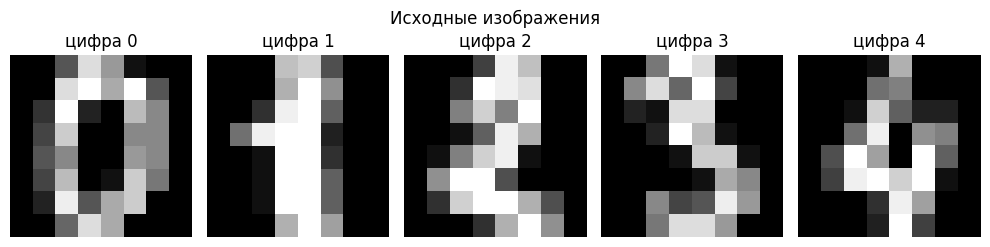

In [9]:
# Загружаем рукописные цифры 8×8
digits = load_digits()
X_img = digits.data / 16.0  # нормируем яркость в диапазон примерно 0..1
y_img = digits.target

print("Объектов:", X_img.shape[0])
print("Признаков на картинку:", X_img.shape[1], "(это 8×8 пикселей)")

# Покажем несколько исходных цифр
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))
for ax, i in zip(axes, range(5)):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"цифра {y_img[i]}")
    ax.axis("off")
plt.suptitle("Исходные изображения")
plt.tight_layout()
plt.show()


Было признаков: 64
Стало компонент: 29
Сохранили дисперсии: 0.955


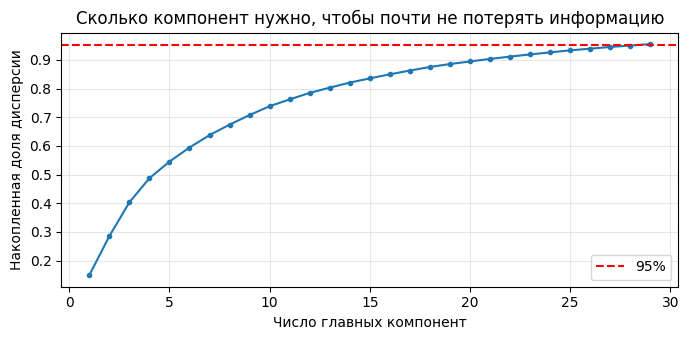

In [10]:
# PCA: оставляем столько компонент, чтобы сохранить 95% дисперсии
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_img)

print("Было признаков:", X_img.shape[1])
print("Стало компонент:", pca.n_components_)
print("Сохранили дисперсии:", round(pca.explained_variance_ratio_.sum(), 3))

# График: как быстро набирается объяснённая дисперсия
cum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, len(cum) + 1), cum, marker="o", markersize=3)
plt.axhline(0.95, color="red", linestyle="--", label="95%")
plt.xlabel("Число главных компонент")
plt.ylabel("Накопленная доля дисперсии")
plt.title("Сколько компонент нужно, чтобы почти не потерять информацию")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


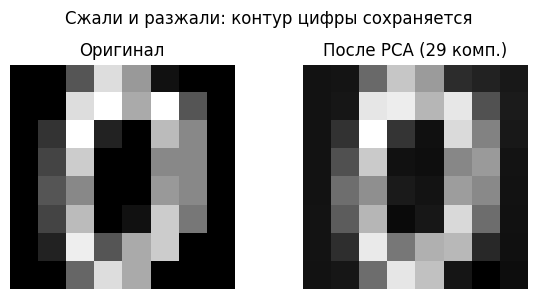

In [11]:
# Восстановление картинки из сжатого представления
idx = 0
original = X_img[idx].reshape(8, 8)
restored = pca.inverse_transform(X_reduced[idx]).reshape(8, 8)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(original, cmap="gray")
ax[0].set_title("Оригинал")
ax[0].axis("off")
ax[1].imshow(restored, cmap="gray")
ax[1].set_title(f"После PCA ({pca.n_components_} комп.)")
ax[1].axis("off")
plt.suptitle("Сжали и разжали: контур цифры сохраняется")
plt.tight_layout()
plt.show()


**Вывод.**  
PCA уменьшает число чисел, которыми описана картинка, но оставляет главное.  
Так экономят память и иногда убирают шум перед обучением модели.


<a id="summary"></a>
## 9. Итог простыми словами

1. **Текст** нельзя сразу скормить LogReg — сначала делают **токены** и **векторы**.  
2. **CountVectorizer** считает слова (мешок слов).  
3. **N-граммы** добавляют короткие словосочетания.  
4. **TF-IDF** усиливает редкие важные слова и ослабляет «мусорные» частые.  
5. Типичный пайплайн спама: `TF-IDF/Count → LogReg или Naive Bayes`.  
6. **Наивный Байес** смотрит, какие слова характерны для класса.  
7. **Картинка** = много пикселей; **PCA** сжимает их до главных компонент.

> Главная мысль: *сложные данные → сначала представление числами → потом обычные модели ML.*
